In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Create folder for project in drive
!mkdir -p "/content/drive/MyDrive/ECG_Project"

In [4]:
!pip install awscli --quiet

# Download dataset to project folder in drive
!aws s3 sync --no-sign-request s3://physionet-open/ptb-xl/1.0.3/ "/content/drive/MyDrive/ECG_Project/ptb-xl-data" --exclude "records500/*"

Streaming output truncated to the last 5000 lines.
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19338_lr.hea to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19338_lr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19340_lr.dat to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19340_lr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19339_lr.dat to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19339_lr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19339_lr.hea to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19339_lr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19341_lr.dat to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19341_lr.dat
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19340_lr.hea to drive/MyDrive/ECG_Project/ptb-xl-data/records100/19000/19340_lr.hea
download: s3://physionet-open/ptb-xl/1.0.3/records100/19000/19341_lr.hea to drive/MyD

In [6]:
import os
import glob

# Confirm count of records to ensure all are saved
dat_files = glob.glob('/content/drive/MyDrive/ECG_Project/ptb-xl-data/records100/**/*.dat', recursive=True)
hea_files = glob.glob('/content/drive/MyDrive/ECG_Project/ptb-xl-data/records100/**/*.hea', recursive=True)

print(f"Total .dat files found: {len(dat_files)}")
print(f"Total .hea files found: {len(hea_files)}")

Total .dat signal tracks found: 21799
Total .hea header tracks found: 21799


In [7]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


In [8]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Plot ecg signal provided at path
def visualize_ecg_from_file(path):
  record = wfdb.rdrecord(path)
  signal = record.p_signal
  lead_names = record.sig_name
  sampling_freq = record.fs  #100
  n_samples = signal.shape[0]
  time = np.arange(n_samples) / sampling_freq

  n_leads = signal.shape[1]
  fig, axes = plt.subplots(n_leads, 1, figsize=(12, 1.5*n_leads), sharex=True)
  for i in range(n_leads):
    axes[i].plot(time, signal[:, i], color='black', linewidth=0.8)
    axes[i].set_ylabel(lead_names[i], rotation=0, labelpad=20)
    axes[i].grid(True, alpha=0.3)

  axes[-1].set_xlabel("Time (s)")
  fig.suptitle(f"ECG Record: {path.split('/')[-1]}", y=1.0)
  plt.tight_layout()
  plt.show()

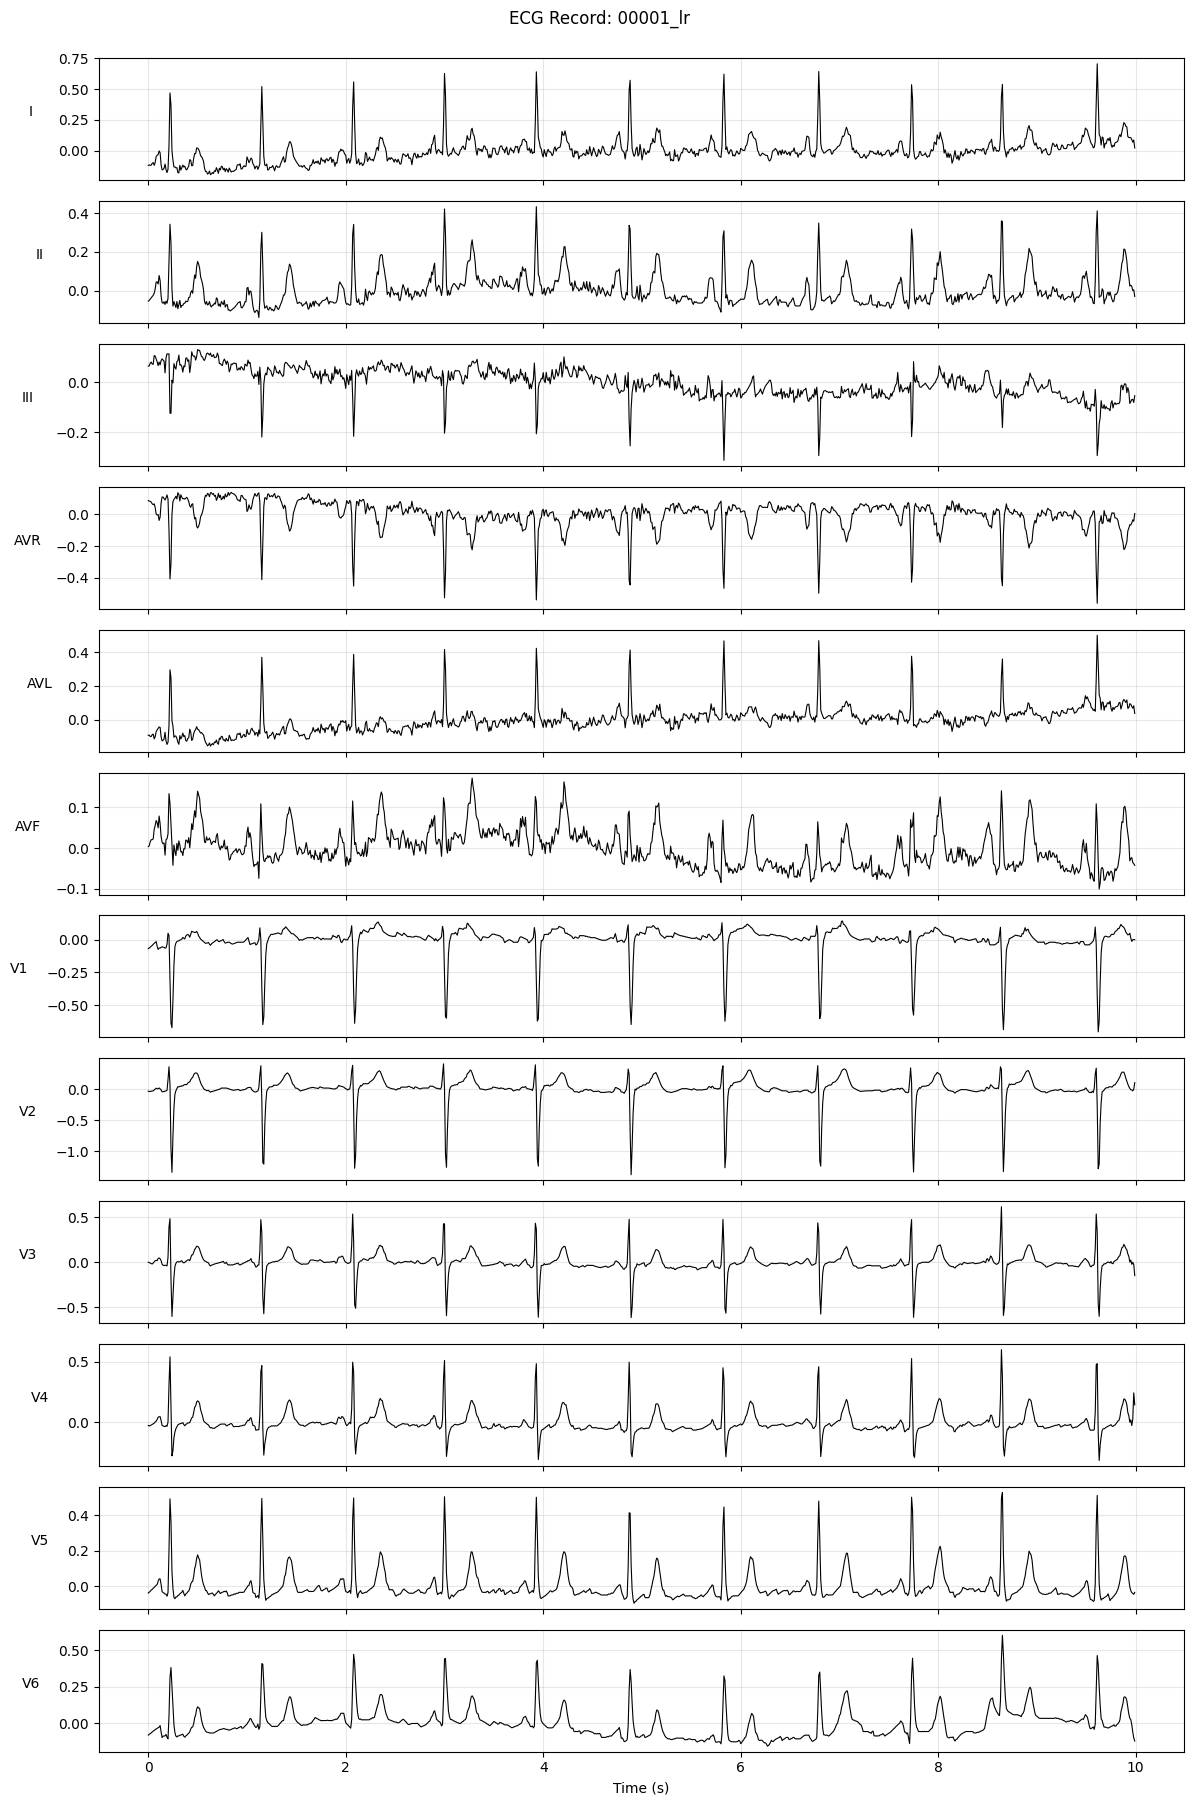

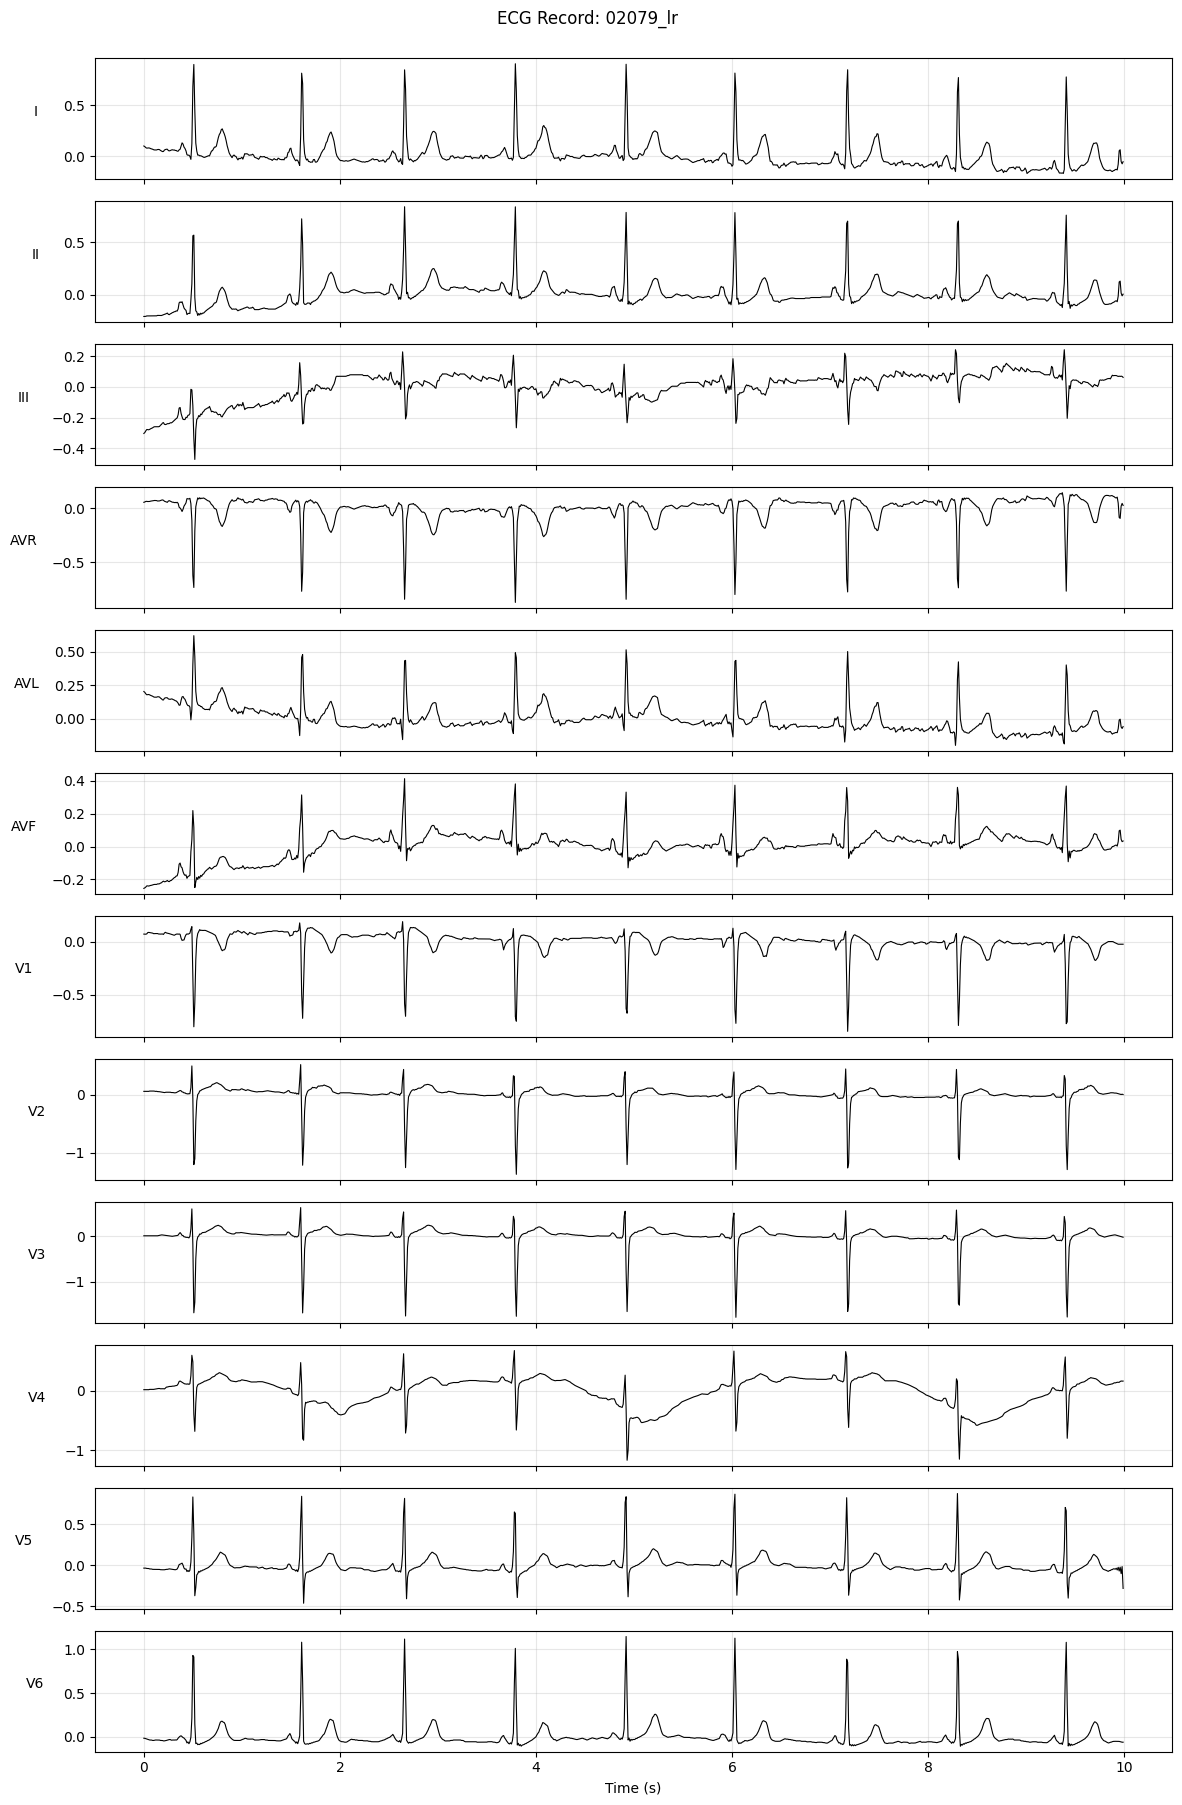

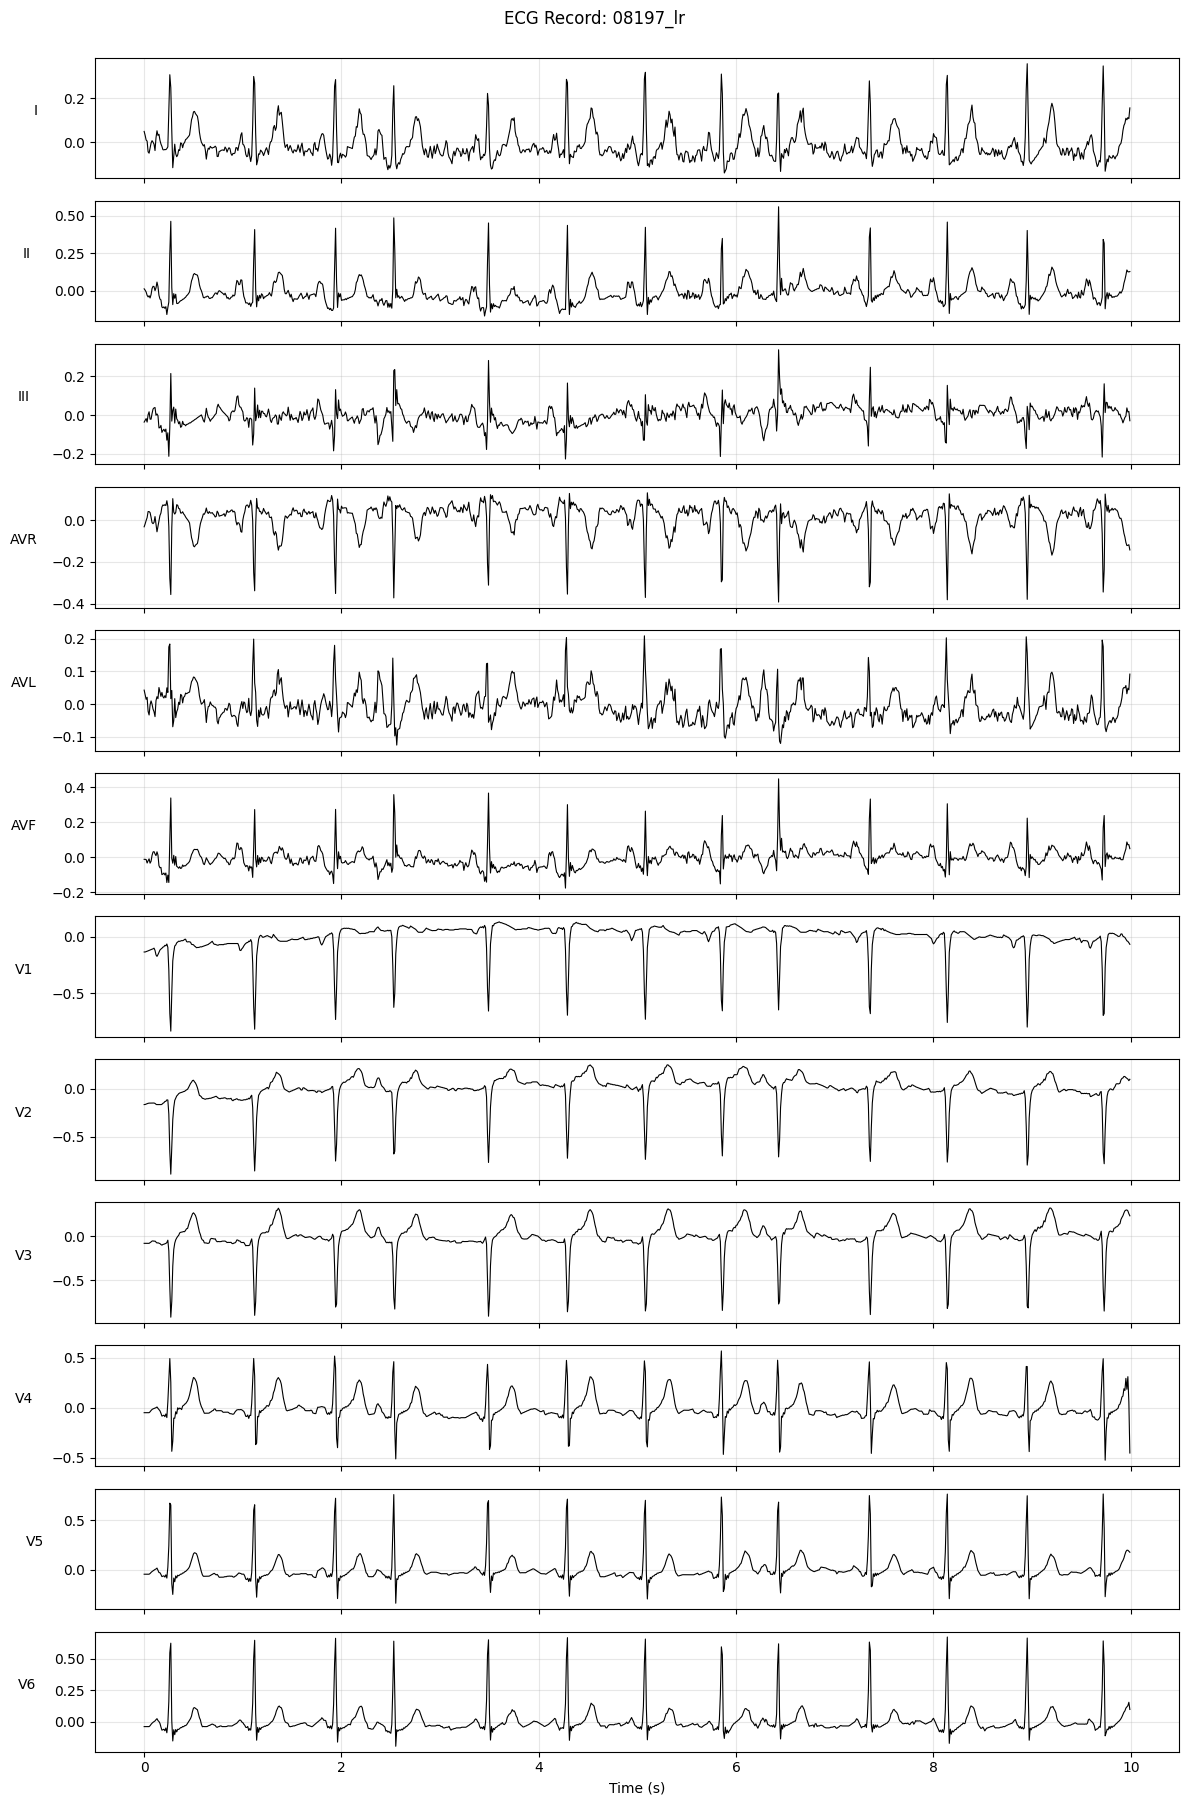

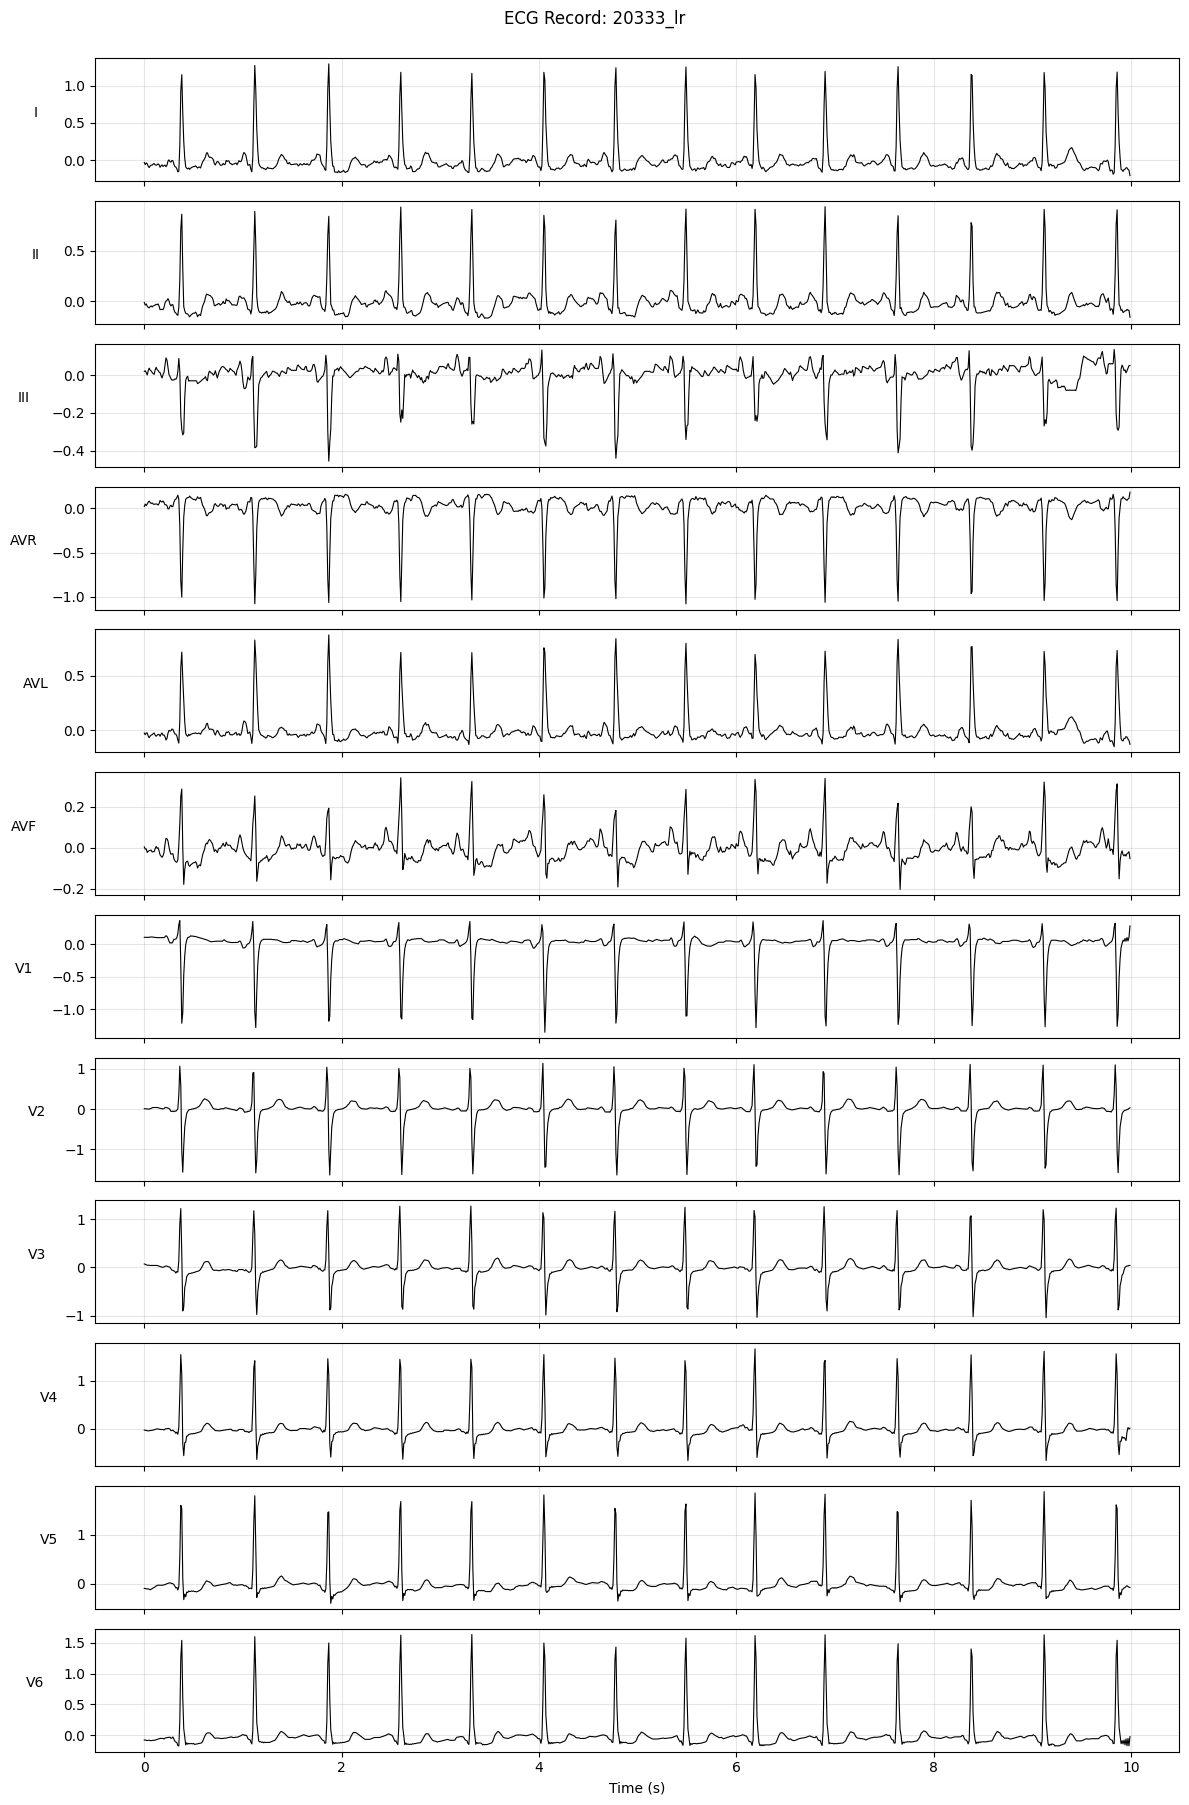

In [11]:
# Visualize some ecg samples from dataset
visualize_ecg_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/00000/00001_lr')

visualize_ecg_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/02000/02079_lr')

visualize_ecg_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/08000/08197_lr')

visualize_ecg_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/20000/20333_lr')

In [9]:
# Retrieve just lead II given a sample file
def get_lead_ii_from_file(path):
  record = wfdb.rdrecord(path)
  lead_names = record.sig_name
  lead_idx = lead_names.index('II')
  signal = record.p_signal[:, lead_idx]
  sampling_freq = record.fs
  return signal, sampling_freq

# Visualize just lead II given a sample file
def visualize_lead_ii_from_file(path):
  signal, sampling_freq = get_lead_ii_from_file(path)
  n_samples = signal.shape[0]
  time = np.arange(n_samples) / sampling_freq

  plt.figure(figsize=(12, 3))
  plt.plot(time, signal, color='black', linewidth=0.8)
  plt.xlabel("Time (s)")
  plt.ylabel("Lead II (mV)")
  plt.title(f"ECG Record: {path.split('/')[-1]}")
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()

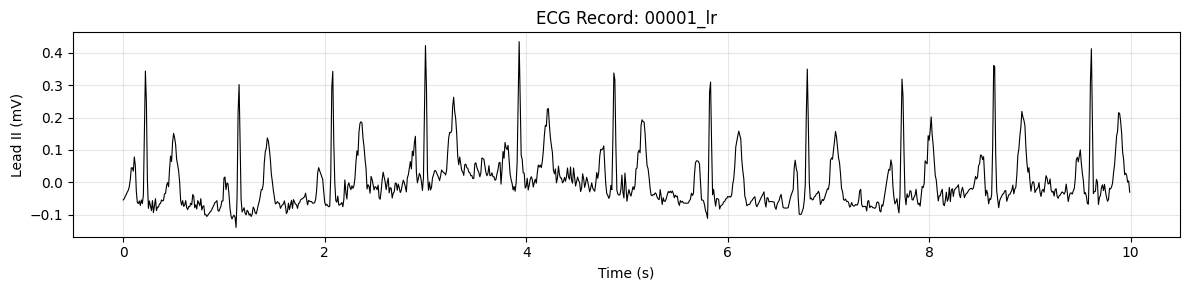

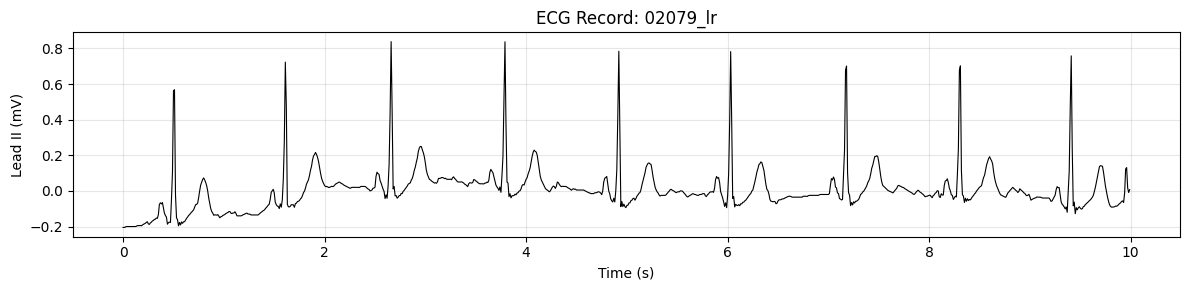

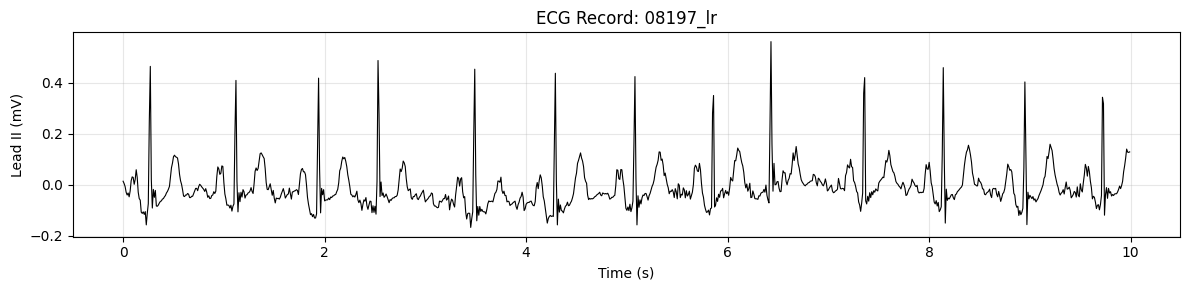

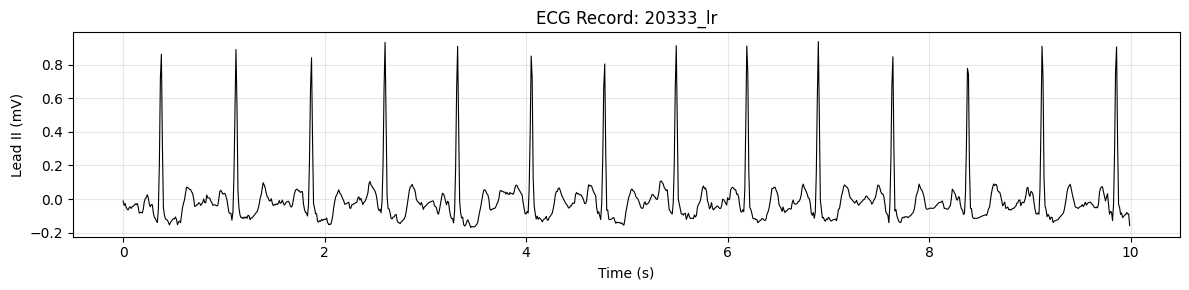

In [10]:
# Visualize lead II of some ecg samples from dataset
visualize_lead_ii_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/00000/00001_lr')

visualize_lead_ii_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/02000/02079_lr')

visualize_lead_ii_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/08000/08197_lr')

visualize_lead_ii_from_file('drive/MyDrive/ECG_Project/ptb-xl-data/records100/20000/20333_lr')